# CNN afinada sobre MNIST · Tema 2 · Sesión 3

**Máster en Ingeniería de Automatización con IA Agéntica · EBIS**
Autor: Manuel Díaz Bendito

Partiendo de la CNN base del notebook anterior, aquí construimos un **modelo afinado** aplicando las buenas prácticas que de verdad marcan la diferencia: arquitectura más profunda, **Batch Normalization**, **Dropout**, **data augmentation**, **early stopping** y **reducción del learning rate**. El objetivo es acercarnos al techo de MNIST (~99.3 %) y, sobre todo, entender *qué aporta cada técnica*.

## 0 · Compatibilidad de hardware (léeme primero)

Este notebook funciona en **cualquier ordenador**. El código detecta automáticamente el mejor dispositivo de cómputo disponible y se adapta a él:

- **CUDA** → GPU NVIDIA (Windows / Linux). El más rápido para entrenar.
- **MPS** → GPUs de Apple Silicon (M1/M2/M3/M4). Acelera mucho en Mac.
- **CPU** → cualquier máquina. Funciona siempre; más lento, pero perfectamente válido para los modelos de este notebook.

No tienes que cambiar nada manualmente: la celda de detección de dispositivo elige sola. Si entrenas en CPU, los tiempos de este notebook siguen siendo de pocos minutos.

## 1 · Importación de librerías

In [ ]:
# %pip install torch torchvision numpy matplotlib scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.manual_seed(42); np.random.seed(42)
print("PyTorch:", torch.__version__)

PyTorch: 2.12.0


## 2 · Detección automática de dispositivo

In [2]:
def elegir_dispositivo():
    """Devuelve el mejor dispositivo disponible: CUDA > MPS > CPU."""
    if torch.cuda.is_available():
        print(f"✅ Usando CUDA (GPU NVIDIA): {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        print("✅ Usando MPS (Apple Silicon)")
        return torch.device("mps")
    print("⚠️  No se ha detectado GPU. Usando CPU (funciona igual, algo más lento).")
    return torch.device("cpu")

device = elegir_dispositivo()
print("Dispositivo seleccionado:", device)

✅ Usando MPS (Apple Silicon)
Dispositivo seleccionado: mps


## 3 · Datos con *data augmentation*

El **data augmentation** genera variaciones realistas de las imágenes de entrenamiento (pequeñas rotaciones y traslaciones) para que la red vea más diversidad y generalice mejor. **Solo se aplica al train**: validación y test usan las imágenes originales.

In [3]:
transform_train = transforms.Compose([
    transforms.RandomRotation(10),                          # ±10 grados
    transforms.RandomAffine(0, translate=(0.1, 0.1)),       # desplazamiento leve
    transforms.ToTensor(),
])
transform_eval = transforms.ToTensor()

full_train = datasets.MNIST(root="./datos", train=True, download=True, transform=transform_train)
# Para validación queremos las imágenes sin augmentar: cargamos una copia con transform_eval
full_train_eval = datasets.MNIST(root="./datos", train=True, download=True, transform=transform_eval)
test_ds = datasets.MNIST(root="./datos", train=False, download=True, transform=transform_eval)

n_val = len(full_train) // 10
idx = torch.randperm(len(full_train), generator=torch.Generator().manual_seed(42))
val_idx, train_idx = idx[:n_val], idx[n_val:]
train_ds = torch.utils.data.Subset(full_train, train_idx.tolist())
val_ds   = torch.utils.data.Subset(full_train_eval, val_idx.tolist())

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 54000 | Val: 6000 | Test: 10000


## 4 · Arquitectura afinada

`[Conv(32) → BN → ReLU] ×2 → MaxPool → Dropout`
`[Conv(64) → BN → ReLU] ×2 → MaxPool → Dropout`
`Flatten → Linear(128) → BN → ReLU → Dropout → Linear(10)`

- **BatchNorm** normaliza las activaciones de cada lote: entrena más rápido y estable.
- **Dropout** apaga aleatoriamente neuronas durante el entrenamiento: combate el sobreajuste.

In [4]:
class CNNAfinada(nn.Module):
    def __init__(self, n_clases=10):
        super().__init__()
        self.bloque1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )                                              # -> (32,14,14)
        self.bloque2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )                                              # -> (64,7,7)
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, n_clases),
        )
    def forward(self, x):
        return self.clasificador(self.bloque2(self.bloque1(x)))

modelo = CNNAfinada().to(device)
print("Parámetros:", sum(p.numel() for p in modelo.parameters()))

Parámetros: 468458


## 5 · Entrenamiento con *early stopping* y *scheduler*

Replicamos en PyTorch los *callbacks* clásicos de Keras:

- **ModelCheckpoint** → guardamos los pesos de la mejor época.
- **ReduceLROnPlateau** → si la validación se estanca, reducimos el learning rate.
- **EarlyStopping** → si no mejora en varias épocas, paramos.

In [5]:
import os
os.makedirs("./pesos", exist_ok=True)
RUTA_PESOS = "./pesos/cnn_afinada_mnist.pt"

def evaluar(modelo, loader):
    modelo.eval(); correctos = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correctos += (modelo(x).argmax(1) == y).sum().item(); total += y.size(0)
    return correctos / total

criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode="max", factor=0.5, patience=2)

num_epocas = 15
paciencia_early = 4      # épocas sin mejorar antes de parar
sin_mejora = 0
mejor_val = 0.0
hist = {"train_loss": [], "val_acc": []}

for epoca in range(num_epocas):
    modelo.train(); perdida = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = criterio(modelo(x), y)
        optimizador.zero_grad(); loss.backward(); optimizador.step()
        perdida += loss.item()
    val_acc = evaluar(modelo, val_loader)
    scheduler.step(val_acc)
    hist["train_loss"].append(perdida/len(train_loader)); hist["val_acc"].append(val_acc)
    print(f"Época {epoca+1:2d}/{num_epocas} | loss {hist['train_loss'][-1]:.4f} | val acc {val_acc*100:.2f} %")
    if val_acc > mejor_val:
        mejor_val = val_acc; sin_mejora = 0
        torch.save(modelo.state_dict(), RUTA_PESOS)
    else:
        sin_mejora += 1
        if sin_mejora >= paciencia_early:
            print(f"Early stopping en la época {epoca+1} (sin mejora en {paciencia_early} épocas)")
            break
print(f"\nMejor val acc: {mejor_val*100:.2f} %")

Época  1/15 | loss 0.3330 | val acc 98.77 %
Época  2/15 | loss 0.1088 | val acc 98.85 %
Época  3/15 | loss 0.0893 | val acc 99.15 %
Época  4/15 | loss 0.0739 | val acc 99.22 %
Época  5/15 | loss 0.0644 | val acc 99.12 %
Época  6/15 | loss 0.0614 | val acc 99.20 %
Época  7/15 | loss 0.0581 | val acc 99.33 %
Época  8/15 | loss 0.0579 | val acc 99.37 %
Época  9/15 | loss 0.0506 | val acc 99.33 %
Época 10/15 | loss 0.0486 | val acc 99.30 %
Época 11/15 | loss 0.0489 | val acc 99.30 %
Época 12/15 | loss 0.0388 | val acc 99.45 %
Época 13/15 | loss 0.0380 | val acc 99.62 %
Época 14/15 | loss 0.0357 | val acc 99.52 %
Época 15/15 | loss 0.0343 | val acc 99.50 %

Mejor val acc: 99.62 %


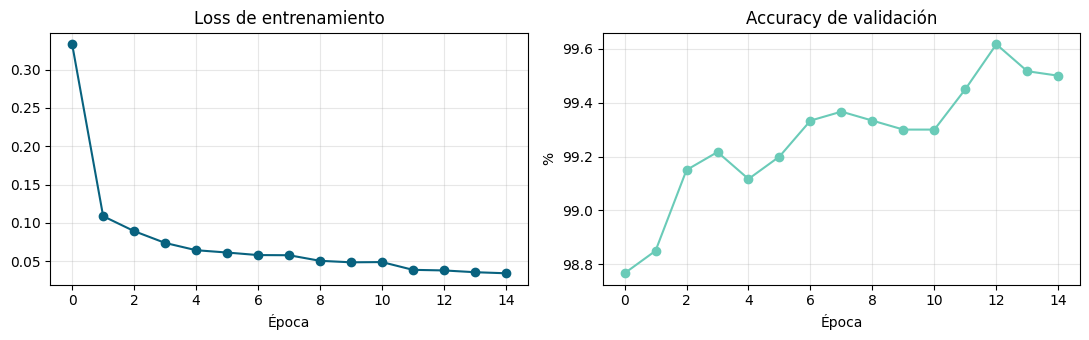

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
a1.plot(hist["train_loss"], marker="o", color="#08627F"); a1.set_title("Loss de entrenamiento"); a1.set_xlabel("Época"); a1.grid(alpha=0.3)
a2.plot([v*100 for v in hist["val_acc"]], marker="o", color="#6ACBB8"); a2.set_title("Accuracy de validación"); a2.set_xlabel("Época"); a2.set_ylabel("%"); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6 · Evaluación final y matriz de confusión

Accuracy test: 99.60 %

              precision    recall  f1-score   support

           0      0.997     0.998     0.997       980
           1      0.994     0.996     0.995      1135
           2      0.996     0.997     0.997      1032
           3      0.994     0.998     0.996      1010
           4      0.999     0.993     0.996       982
           5      0.998     0.996     0.997       892
           6      0.996     0.995     0.995       958
           7      0.996     0.994     0.995      1028
           8      0.997     0.996     0.996       974
           9      0.994     0.998     0.996      1009

    accuracy                          0.996     10000
   macro avg      0.996     0.996     0.996     10000
weighted avg      0.996     0.996     0.996     10000



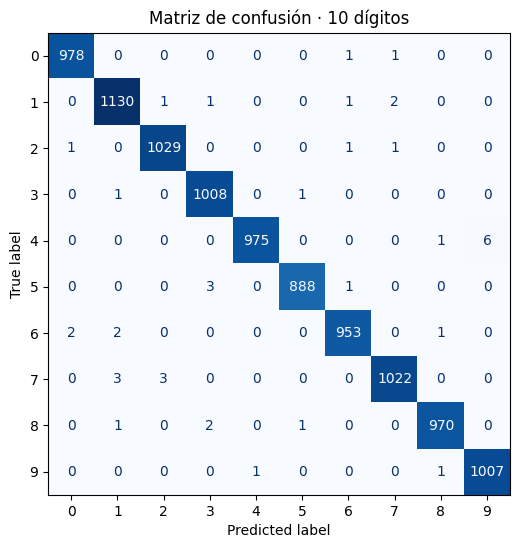

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

modelo.eval(); y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        y_pred.extend(modelo(x.to(device)).argmax(1).cpu().tolist()); y_true.extend(y.tolist())

print(f"Accuracy test: {np.mean(np.array(y_true)==np.array(y_pred))*100:.2f} %\n")
print(classification_report(y_true, y_pred, digits=3))
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Matriz de confusión · 10 dígitos"); plt.show()

## 7 · Lo que has aprendido

Frente a la CNN base, el modelo afinado incorpora **profundidad, BatchNorm, Dropout y data augmentation**, además de un entrenamiento gestionado con **early stopping** y **scheduler de learning rate**. El resultado es un modelo que generaliza mejor y se acerca al techo práctico de MNIST.

> Estas mismas técnicas son las que usaremos en el siguiente notebook sobre **CIFAR-10**, un problema en color mucho más difícil que MNIST.